# Mexico Real Estate Analysis
## Correlation Analysis

### Research Question

> How strongly is property size associated with property price,
> and does this relationship vary across property types and states?

### Objective

This notebook quantifies relationships identified during the exploratory
analysis using correlation analysis.

The analysis focuses on:

- Pearson correlation between property size and price
- Correlations among numerical variables
- Variation in the size-price relationship across property types
- Variation across states
- A size-normalized price measure
- Limitations of correlation for real estate analysis

In [480]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data_path = "../data/mexico-real-estate-combined-clean.csv"

df = pd.read_csv(data_path)


In [481]:
print(f"Dataset: {df.shape[0]:,} observations × {df.shape[1]} variables")

Dataset: 1,736 observations × 6 variables


## 2. Pearson Correlation

Pearson's correlation coefficient measures the direction and strength
of a linear relationship between two numerical variables.

The coefficient ranges from -1 to 1:

- `1` indicates a perfect positive linear relationship.
- `0` indicates no linear association.
- `-1` indicates a perfect negative linear relationship.

Correlation measures association, not causation.

In [482]:
area_price_corr = df["area_m2"].corr(df["price_usd"])

print(f"Area-price correlation: {area_price_corr:.4f}")

Area-price correlation: 0.5855


### Interpretation

The correlation between property area and price is **0.5855**, indicating a
moderate positive linear association.

In this dataset, larger properties tend to have higher listed prices.
However, the correlation is well below `1.0`, showing that area alone does
not account for all price variation.

Other characteristics, such as property type and location, may also be
associated with differences in listed prices.

## 3. Correlation Matrix

A correlation matrix provides a compact view of the linear relationships
among the numerical variables in the dataset.

In [483]:
# Correlation matrix
numeric_columns = [
    "lat",
    "lon",
    "area_m2",
    "price_usd"
]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix


,lat,lon,area_m2,price_usd
lat,1.000000,-0.480231,0.082314,-0.085868
lon,-0.480231,1.000000,0.095522,0.032815
area_m2,0.082314,0.095522,1.000000,0.585518
price_usd,-0.085868,0.032815,0.585518,1.000000


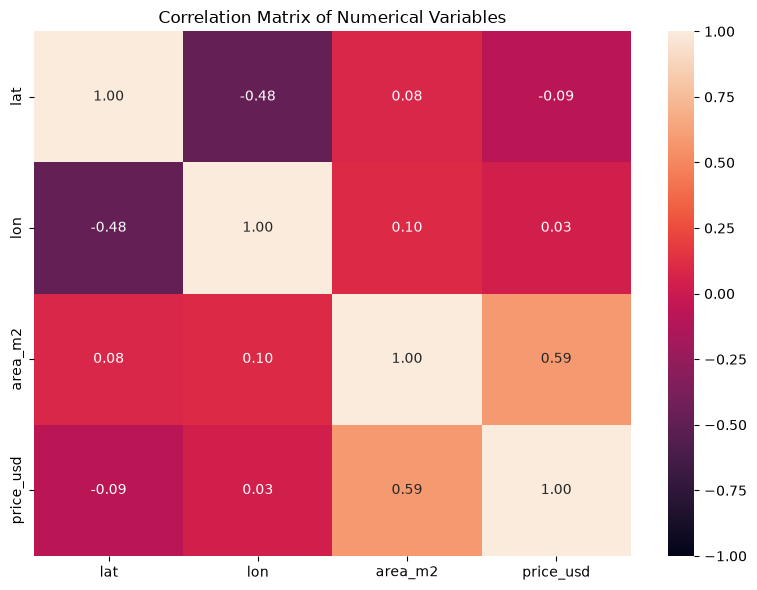

In [484]:
# Visualizing the correlation matrix using a heat map
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    ax=ax
)

ax.set_title("Correlation Matrix of Numerical Variables")

plt.tight_layout()
plt.show()

### Interpretation

Among the numerical variables examined, **area_m2 and price_usd have the
strongest positive relationship, with a correlation of approximately `0.59`**.

Latitude and longitude show weaker correlations with price than property
area. However, geographic coordinates represent position rather than the
full range of location characteristics, such as neighborhood conditions,
accessibility, amenities, and local market conditions.

The matrix therefore summarizes the observed relationships without fully
capturing the role of location in property prices.

## 4. Correlation by property type

The overall correlation combines different property types.

The area-price relationship is therefore examined separately to determine
whether the observed association changes between houses and apartments.

In [485]:
property_type_corr = (
    df.groupby("property_type")[["area_m2", "price_usd"]]
    .corr()
    .iloc[:, 1]
    .xs("area_m2", level=1)
    .rename("area_price_corr")
    
)
property_type_corr

property_type
apartment    0.519021
house        0.719280
Name: area_price_corr, dtype: float64

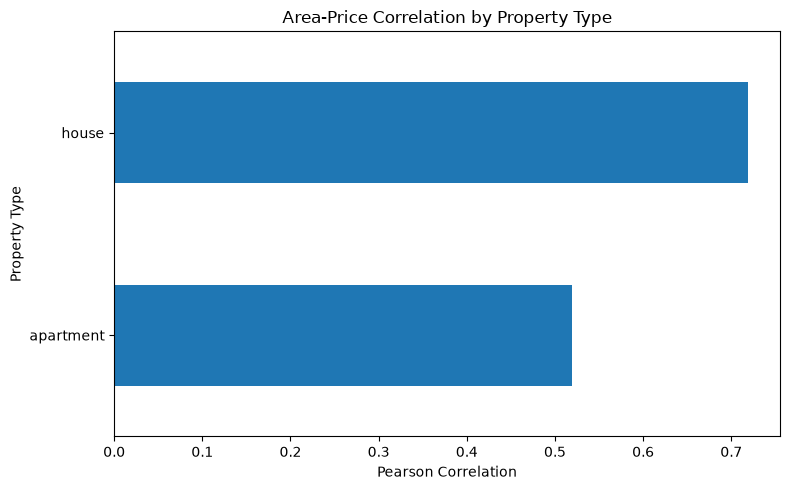

In [486]:
fig, ax = plt.subplots(figsize=(8, 5))

property_type_corr.sort_values().plot(
    kind="barh",
    ax=ax
)

ax.set_title("Area-Price Correlation by Property Type")
ax.set_xlabel("Pearson Correlation")
ax.set_ylabel("Property Type")

plt.tight_layout()
plt.show()

### Interpretation

The area-price correlation differs by property type.

For **apartments**, the correlation is approximately **0.52**, while for
**houses** it is approximately **0.72**.

The linear association between size and price is therefore stronger for
houses than for apartments in this dataset.

These results describe associations within the observed listings and do not
establish that property type causes the difference.

## 5. Correlation by State

The national correlation summarizes all properties together.

To examine geographic variation, the area-price correlation is calculated
separately for each state.

The number of listings is retained alongside each correlation because
estimates based on very small samples can be less stable.

In [487]:
state_corr = (
    df.groupby("state")[["area_m2", "price_usd"]]
    .corr()
    .iloc[:,1]
    .xs("area_m2", level = 1)
    .rename("area_price_corr")
)
state_counts = (
  df["state"]
  .value_counts()
  .rename("listing_count")
 )
state_analysis = (
    pd.concat([state_counts, state_corr], axis = 1)
    .sort_values("area_price_corr", ascending = False)
)

state_analysis.head(10)

,listing_count,area_price_corr
state,,
Zacatecas,2,1.000000
Colima,5,0.988235
Sonora,12,0.911524
Durango,7,0.909258
Baja California Sur,15,0.880583
Aguascalientes,10,0.873437
San Luis Potosí,55,0.855196
Morelos,160,0.849808
Campeche,3,0.824161


### Filtering for Adequate Sample Size

A minimum of 20 listings is used as a practical screening threshold.
This reduces attention to correlations calculated from very small groups.

The threshold is a practical choice for this analysis rather than a
universal statistical rule.

In [488]:
# Reliable state analysis correlation results
state_analysis_reliable = (
    state_analysis[
    state_analysis["listing_count"]>=20
    ]
    .sort_values("area_price_corr", ascending = False)
)
state_analysis_reliable

,listing_count,area_price_corr
state,,
San Luis Potosí,55,0.855196
Morelos,160,0.849808
Querétaro,128,0.819374
Puebla,95,0.772550
Tamaulipas,48,0.763998
Chiapas,55,0.755961
Yucatán,171,0.740413
Guerrero,49,0.674457
Baja California,29,0.658334


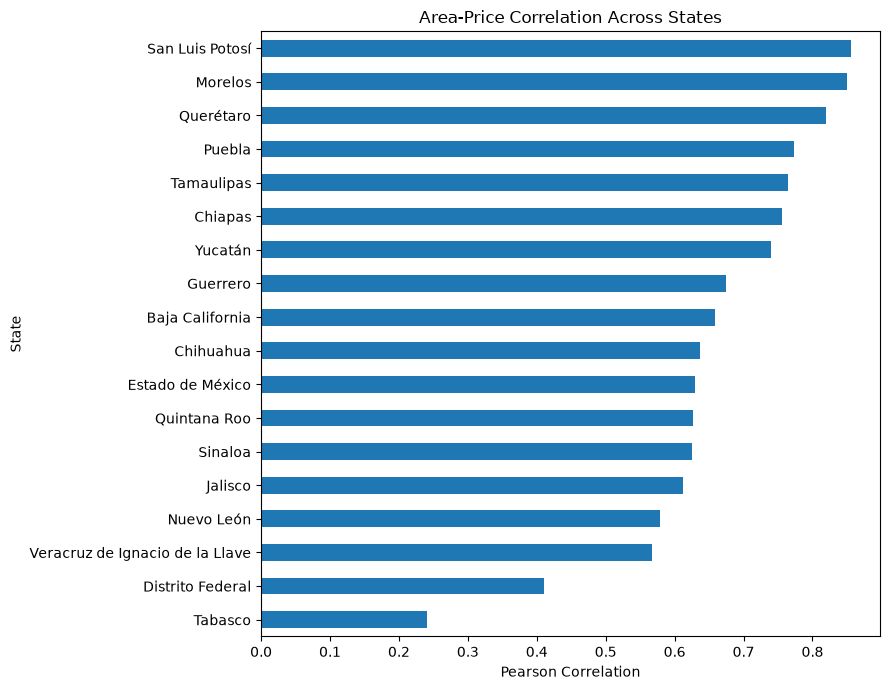

In [489]:
plot_data = (
    state_analysis_reliable
    .sort_values("area_price_corr")
)

fig, ax = plt.subplots(figsize=(9, 7))

plot_data["area_price_corr"].plot(
    kind="barh",
    ax=ax
)

ax.set_title("Area-Price Correlation Across States")
ax.set_xlabel("Pearson Correlation")
ax.set_ylabel("State")

plt.tight_layout()
plt.show()

### Interpretation

The area-price relationship varies substantially across states.

Among states with at least 20 listings, the correlation ranges from
**0.24 in Tabasco** to **0.86 in San Luis Potosí**.

Several states show strong positive associations:

- **San Luis Potosí:** `r = 0.86`, `n = 55`
- **Morelos:** `r = 0.85`, `n = 160`
- **Querétaro:** `r = 0.82`, `n = 128`

The relationship is weaker in:

- **Distrito Federal:** `r = 0.41`, `n = 303`
- **Tabasco:** `r = 0.24`, `n = 20`

These results show that the strength of the size-price association is not
consistent across the states represented in the dataset.

The difference between Distrito Federal (`n = 303`, `r = 0.41`) and
San Luis Potosí (`n = 55`, `r = 0.86`) also illustrates that sample size
and correlation strength describe different aspects of the data.

Correlation alone does not explain why the relationships differ between
states.

## 6. Price per Square Meter

Total property price is naturally influenced by property size.

To examine listed value on a size-normalized basis, I calculate:

`price_per_m2 = price_usd / area_m2`

This allows properties of different sizes to be compared using their
listed price per square meter.

In [490]:
df["price_per_m2"] = (
    df["price_usd"] / df["area_m2"]
)

df[[
    "area_m2",
    "price_usd",
    "price_per_m2"
]].head()

,area_m2,price_usd,price_per_m2
0,150.0,67965.56,453.103733
1,186.0,63223.78,339.912796
2,82.0,84298.37,1028.028902
3,150.0,94308.80,628.725333
4,205.0,105191.37,513.128634


### Example

The first five observations illustrate why price per m² provides a
different perspective from total price.

For example, the **82 m² property is listed at approximately $1,028 per m²**,
while the **186 m² property is listed at approximately $340 per m²**.

Although the second property is substantially larger, its listed price per
square meter is lower.

This demonstrates that larger properties do not necessarily have higher
size-normalized prices.

## 6. Price per Square Meter

Total property price is naturally influenced by property size. To examine
listed value independently of total property area, I calculate price per
square meter:

`price_per_m2 = price_usd / area_m2`

This provides a size-normalized measure that allows properties of different
sizes to be compared on the same basis.

In [491]:
# price_per_m2 correlation with area
area_price_m2_corr = (
    df["area_m2"].corr(df["price_per_m2"])
)

print(
    f"Area vs. price per m² correlation: "
    f"{area_price_m2_corr:.4f}"
)

Area vs. price per m² correlation: -0.2760


### Interpretation

The correlation between property area and price per m² is shown above.

This relationship should be interpreted separately from the **0.5855
correlation between area and total price** because price per m² is a
size-normalized measure.

The comparison shows that property size can have a different relationship
with total listed price than with the listed price per square meter.

Price per m² therefore provides an additional perspective for comparing
properties of different sizes.

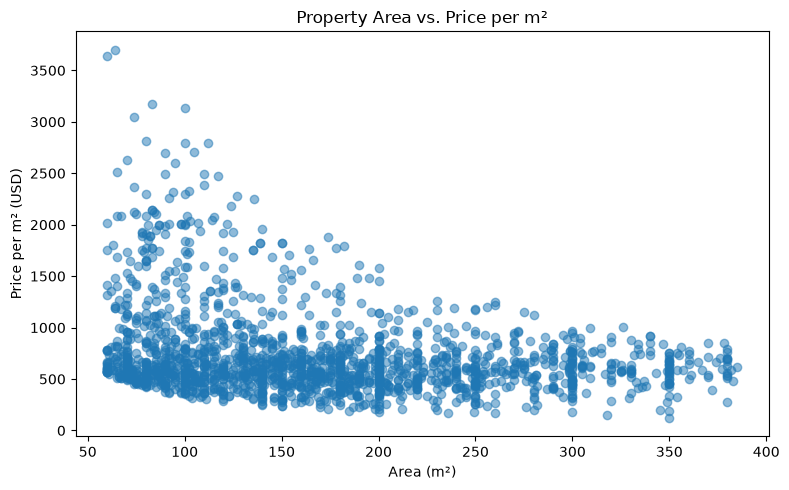

In [492]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    df["area_m2"],
    df["price_per_m2"],
    alpha=0.5
)

ax.set_title("Property Area vs. Price per m²")
ax.set_xlabel("Area (m²)")
ax.set_ylabel("Price per m² (USD)")

plt.tight_layout()
plt.show()

## Key Findings

- **Size and price:** Property area and price have a Pearson correlation of
  **0.5855**, indicating a moderate positive linear association.
- **Property type:** The correlation is approximately **0.52 for apartments**
  and **0.72 for houses**, showing that the strength of the association
  differs by property type.
- **State:** Among states with at least 20 listings, correlations range from
  **0.24 in Tabasco** to **0.86 in San Luis Potosí**.
- **Price per m²:** The size-normalized measure provides a different
  perspective from total property price.

Overall, property size is positively associated with price, but the strength
of this association varies across different segments of the dataset.

## Limitations

Correlation identifies association, not causation, and Pearson correlation
captures only linear relationships.

The results may also be affected by extreme observations and differences
in sample size across states.

Latitude and longitude provide geographic position but do not capture the
full range of location-related characteristics, such as neighborhood
conditions, accessibility, amenities, or local market conditions.

The analysis therefore identifies relationships worth investigating further
rather than providing a complete explanation of property prices.

## Conclusion

Property area has a **moderate positive correlation with price (`r = 0.5855`)**,
indicating that larger properties tend to have higher listed prices in this
dataset.

However, the strength of this relationship varies across property types
and states. For example, the correlation is approximately **0.52 for
apartments** and **0.72 for houses**, while state-level correlations range
from **0.24 in Tabasco to 0.86 in San Luis Potosí** among states with at
least 20 listings.

These results provide a quantitative foundation for the next stage of the
analysis: using regression to examine property size and location jointly
rather than evaluating each relationship separately.